ENT / Eye / Oral  

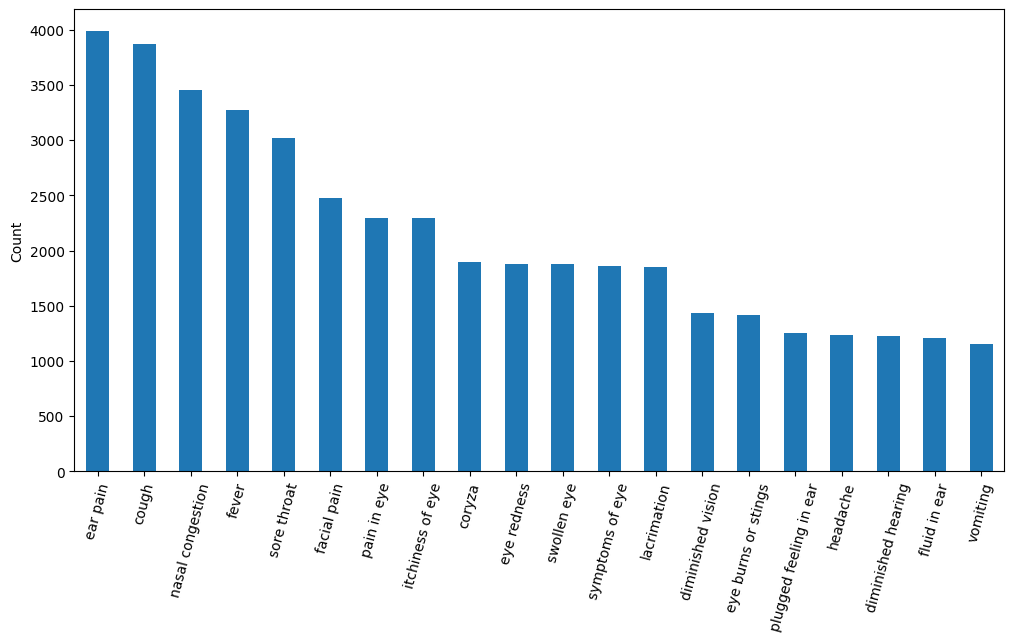

Random Forest Accuracy: 0.9516
                                precision    recall  f1-score   support

               acute sinusitis       0.85      0.88      0.86       166
                conjunctivitis       0.96      0.95      0.96       165
 conjunctivitis due to allergy       0.95      0.95      0.95       243
              cornea infection       0.93      0.93      0.93       163
                 dental caries       0.97      0.98      0.98       237
               ear drum damage       0.97      0.95      0.96       164
                   gum disease       0.97      0.97      0.97       161
          macular degeneration       0.98      0.98      0.98       163
                 nose disorder       0.94      0.90      0.92       244
otitis externa (swimmer's ear)       0.95      0.96      0.95       162
                  otitis media       0.92      0.95      0.94       161
                  strep throat       0.98      0.99      0.98       242
                          stye  

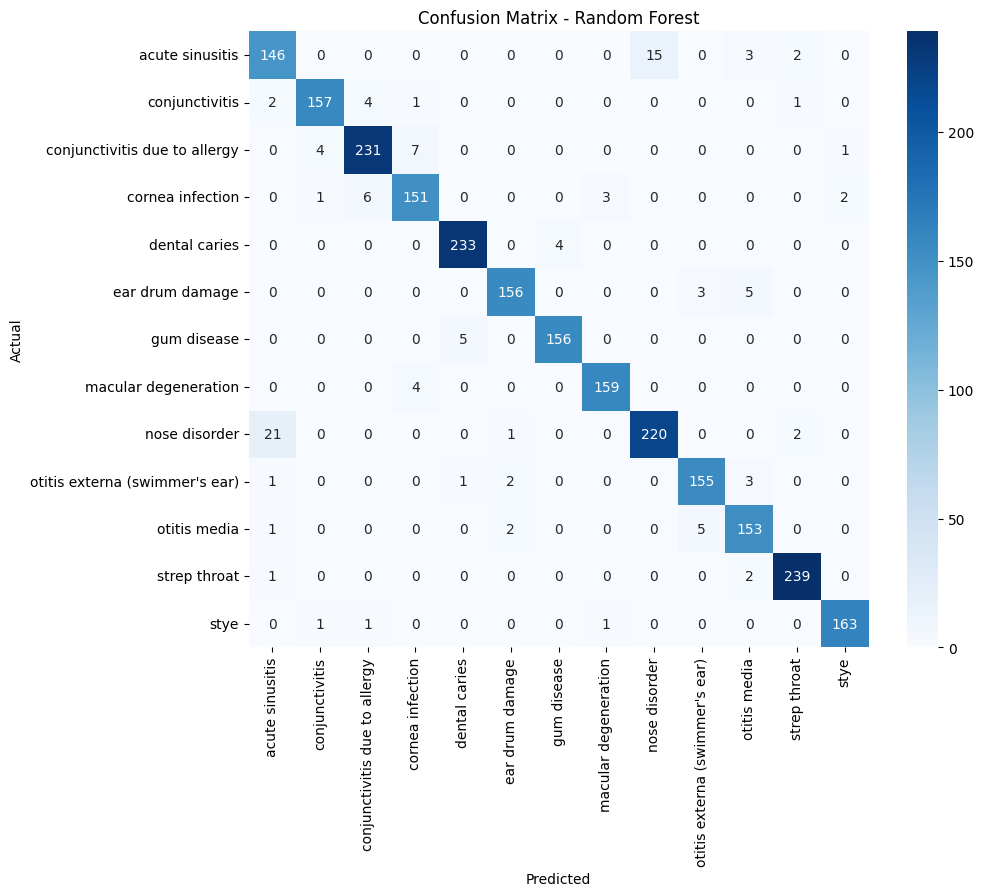

c:\Users\Admin\AppData\Local\Programs\Python\Python311\Lib\site-packages\xgboost\training.py:183: UserWarning: [19:51:33] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:738: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


XGBoost Accuracy: 0.9565
                                precision    recall  f1-score   support

               acute sinusitis       0.85      0.89      0.87       166
                conjunctivitis       0.98      0.95      0.97       165
 conjunctivitis due to allergy       0.95      0.95      0.95       243
              cornea infection       0.93      0.93      0.93       163
                 dental caries       0.99      0.98      0.99       237
               ear drum damage       0.96      0.98      0.97       164
                   gum disease       0.98      0.99      0.98       161
          macular degeneration       0.98      0.98      0.98       163
                 nose disorder       0.94      0.91      0.92       244
otitis externa (swimmer's ear)       0.97      0.95      0.96       162
                  otitis media       0.93      0.95      0.94       161
                  strep throat       0.98      0.99      0.98       242
                          stye       0

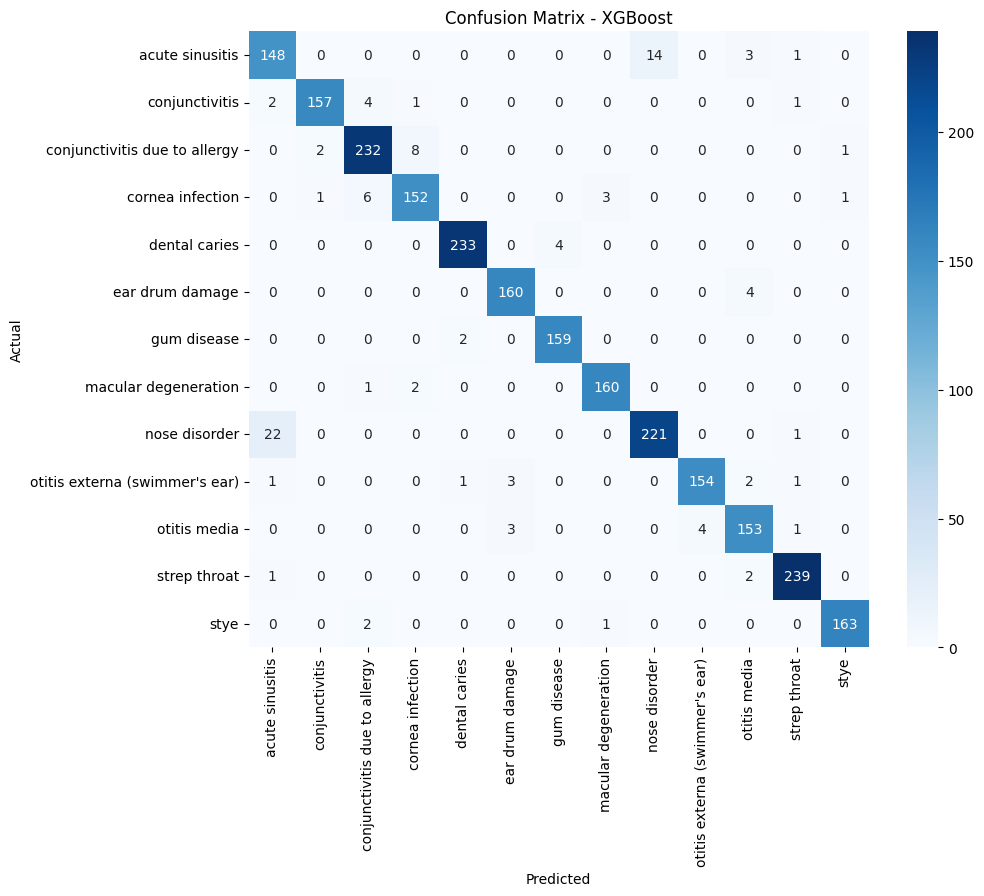

C:\Users\Admin\AppData\Local\Temp\ipykernel_10416\1994960614.py:67: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")


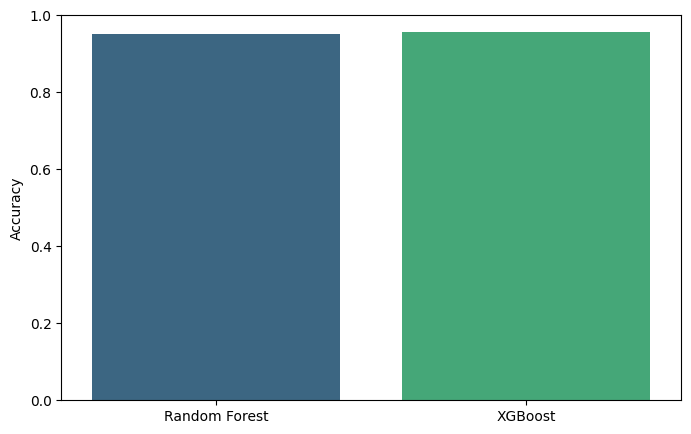

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score
import xgboost as xgb

df = pd.read_csv("Diseases_and_Symptoms_dataset.csv")

disease_col = 'diseases'
symptom_cols = [c for c in df.columns if c != disease_col]

def load_domain(df, domain_diseases):
    df_domain = df[df[disease_col].isin(domain_diseases)].copy()
    selected_symptoms = df_domain[symptom_cols].sum()[lambda x: x>0].index.tolist()
    X = df_domain[selected_symptoms]
    y = df_domain[disease_col]
    le = LabelEncoder()
    y_encoded = le.fit_transform(y)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y_encoded, test_size=0.2, random_state=42, stratify=y_encoded
    )
    return X_train, X_test, y_train, y_test, le, selected_symptoms, df_domain

ent_eye_oral_diseases = [
    "acute sinusitis", "cornea infection", "otitis media", "gum disease",
    "conjunctivitis due to allergy", "macular degeneration", "nose disorder",
    "dental caries", "stye", "otitis externa (swimmer's ear)",
    "ear drum damage", "conjunctivitis", "strep throat"
]

X_train, X_test, y_train, y_test, le, selected_symptoms, df_ent = load_domain(df, ent_eye_oral_diseases)

symptom_counts = df_ent[selected_symptoms].sum().sort_values(ascending=False)

plt.figure(figsize=(12,6))
symptom_counts.head(20).plot(kind='bar')
plt.ylabel('Count')
plt.xticks(rotation=75)
plt.show()

models = {
    "Random Forest": RandomForestClassifier(n_estimators=500, class_weight='balanced', random_state=42),
    "XGBoost": xgb.XGBClassifier(use_label_encoder=False, eval_metric='mlogloss', random_state=42, learning_rate=0.3, n_estimators=500)
}

results = {}
for name, model in models.items():
    model.fit(X_train, y_train)
    y_pred = model.predict(X_test)
    acc = accuracy_score(y_test, y_pred)
    results[name] = acc
    print(f"{name} Accuracy: {acc:.4f}")
    print(classification_report(y_test, y_pred, target_names=le.classes_))
    cm = confusion_matrix(y_test, y_pred)
    plt.figure(figsize=(10,8))
    sns.heatmap(cm, annot=True, fmt='d', xticklabels=le.classes_, yticklabels=le.classes_, cmap='Blues')
    plt.ylabel('Actual')
    plt.xlabel('Predicted')
    plt.title(f'Confusion Matrix - {name}')
    plt.show()

plt.figure(figsize=(8,5))
sns.barplot(x=list(results.keys()), y=list(results.values()), palette="viridis")
plt.ylabel("Accuracy")
plt.ylim(0,1)
plt.show()
